# Salary Prediction

Corresponding  with this notebook is a slide deck where you will need to update all the portions in red.  Completing the notebook will provide all the results needed for the slides.  **Correctly completing the slides is a required part of the project.**

https://docs.google.com/presentation/d/10MVkMfx3qChUqR26Pi_0UY0wE4ZeZF2uiKWAVW3D_7U/edit?slide=id.g305b2e72063_0_231#slide=id.g305b2e72063_0_231 


## Table of Contents
- [Introduction](#intro)
- [Part I - Descriptive Statistics](#descriptive)
- [Part II - Regression](#regression)
- [Part III - Interpret Results](#interpret)


<a id='intro'></a>
### Introduction

Linear Regression is very commonly performed by data analysts and data scientists.  For this project, you will be working to understand the results of a Linear Regression model associated with salaries.  Your goal is to work through this notebook to understand what variables are related to salary, and how exactly they are related.

As a final check, assure you meet all the criteria on the rubric.

<a id='descriptive'></a>
#### Part I - Descriptive Statistics

To get started, let's import our libraries.

In [1]:
import pandas as pd
import numpy as np
import random
import matplotlib.pyplot as plt
random.seed(0)

For each of the parts of question `1` notice links to [pandas documentation](https://pandas.pydata.org/) is provided to assist with answering the questions.  Though there are other ways you could solve the questions, the documentation is provided to assist you with one fast way to find the answer to each question.


`1.a)` Now, read in the `salary_data.csv` data. Store it in `df`. Read in the dataset and take a look at the top few rows here. **This question is completed for you**:

In [2]:
df = pd.read_csv('salary_data.csv')
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


`b)` Use the below cell to find the number of rows in the dataset. [Helpful pandas link - `Dataframe.shape`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.shape.html#pandas.DataFrame.shape)

In [3]:
df.shape[0]

375

`c)` Do any of the rows have missing values? [Helpful Pandas Link One](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.isnull.html) and [Helpful Pandas Link Two](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.sum.html)  

If there are missing values, determine a method for dealing with them.

In [4]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

Since there are only 2 rows with missing values, I've decided to drop them from the dataset. This will leave 373 rows (employees).

In [5]:
df.dropna(inplace=True)

I will now verify that there aren't any null values.

In [6]:
df.isnull().sum()

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64

`d)` How many employees are in each `Education Level`? Build a bar chart to show the count of employees in each level.

In [7]:
df['Education Level'].value_counts()

Education Level
Bachelor's    224
Master's       98
PhD            51
Name: count, dtype: int64

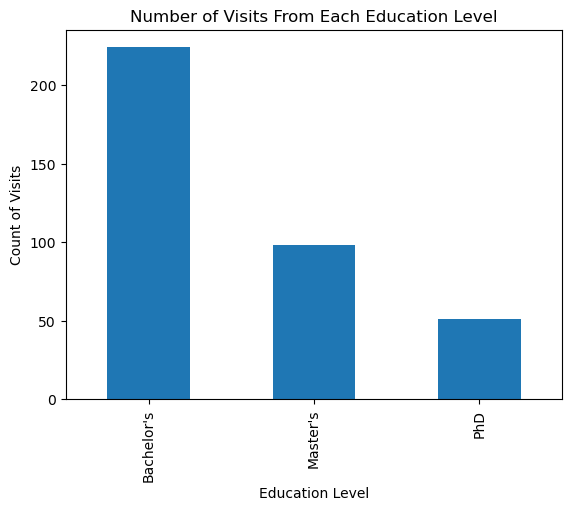

In [8]:
# bar chart of results - this part is done for you
df['Education Level'].value_counts().plot(kind='bar');
plt.title('Number of Visits From Each Education Level');
plt.ylabel('Count of Visits');
plt.show();

`e)` What are the possible values for `Salary`?  What does the distribution of `Salary` look like?

In [9]:
df['Salary'].describe()

count       373.000000
mean     100577.345845
std       48240.013482
min         350.000000
25%       55000.000000
50%       95000.000000
75%      140000.000000
max      250000.000000
Name: Salary, dtype: float64

In [10]:
df['Salary'].unique()

array([ 90000.,  65000., 150000.,  60000., 200000.,  55000., 120000.,
        80000.,  45000., 110000.,  75000., 140000., 130000.,  40000.,
       125000., 115000.,  35000., 180000., 190000.,  50000., 250000.,
       170000., 160000.,  85000.,  95000., 105000.,  70000., 100000.,
        30000., 135000., 220000., 175000., 185000., 145000., 155000.,
          350.])

This shows that salary values range from $350 to $250,000 with many unique values. The following histogram displays the distribution, which is right skewed. The mean is around $100,000, with the most values falling between $40,000 and $100,000.

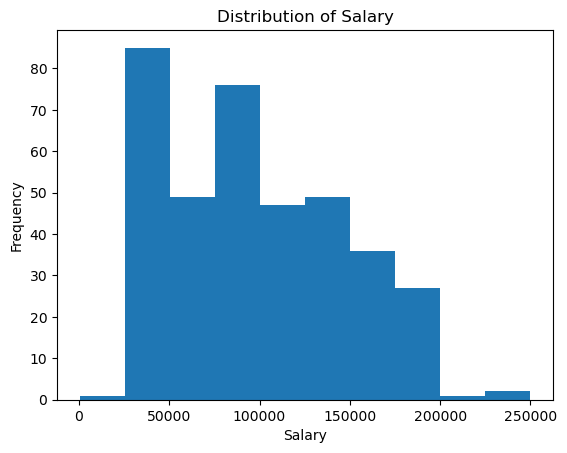

In [11]:
df['Salary'].plot(kind='hist', bins=10);
plt.title('Distribution of Salary');
plt.xlabel('Salary');
plt.ylabel('Frequency');
plt.show();

<a id='regression'></a>
#### Part II - Regression

`1.` Now that you have had a chance to learn more about the dataset, let's look more at how different factors are related to `Salary`.

`a)` Consider average salary by gender, is there evidence that salaries are higher for one gender over the other?

In [12]:
salaries_by_gender = df.groupby('Gender')['Salary'].mean()
salaries_by_gender

Gender
Female     97011.173184
Male      103867.783505
Name: Salary, dtype: float64

Reviewing the averages above provides evidence that male ($103,867.78) salaries are higher than women's ($97,011.17).

`b)` Consider average salary by education level, is there evidence that salaries are higher for increased education?

In [13]:
salaries_by_education = df.groupby('Education Level')['Salary'].mean()
salaries_by_education

Education Level
Bachelor's     74756.026786
Master's      129795.918367
PhD           157843.137255
Name: Salary, dtype: float64

The averages indicate that salaries rise with education level, as bachelor's degree holders earn the least while PhD holders earn the most. The bar chart below visualizes the comparison.

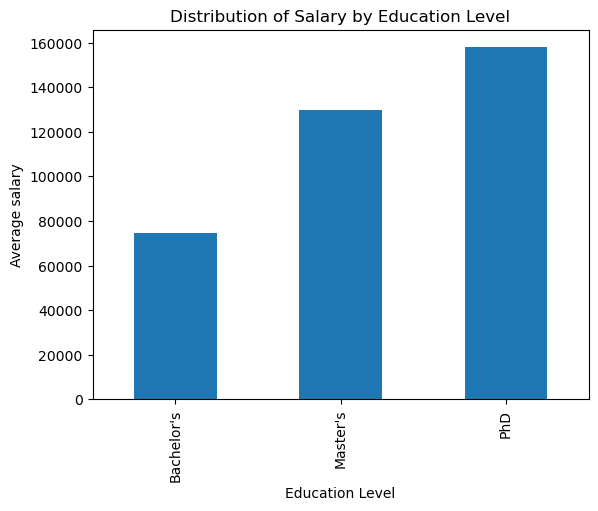

In [14]:
salaries_by_education.plot(kind='bar');
plt.title('Distribution of Salary by Education Level');
plt.xlabel('Education Level');
plt.ylabel('Average salary');
plt.show();

`c)` Consider average salary by years of experience, is there evidence that salaries are associated with increased years of experience?

In [15]:
salary_by_experience = df.groupby('Years of Experience')['Salary'].mean()
salary_by_experience

Years of Experience
0.0      33333.333333
0.5      35000.000000
1.0      37857.142857
1.5      36279.166667
2.0      41774.193548
3.0      51166.666667
4.0      58500.000000
5.0      64117.647059
6.0      83750.000000
7.0      84444.444444
8.0      88800.000000
9.0     101818.181818
10.0    100555.555556
11.0    100500.000000
12.0    105000.000000
13.0    120000.000000
14.0    125769.230769
15.0    134375.000000
16.0    157500.000000
17.0    143000.000000
18.0    149615.384615
19.0    166333.333333
20.0    168846.153846
21.0    173846.153846
22.0    162222.222222
23.0    177500.000000
24.0    250000.000000
25.0    200000.000000
Name: Salary, dtype: float64

In [16]:
df['Years of Experience'].corr(df['Salary'])

np.float64(0.9303377227618356)

Looking at salary trends from year to year, it appears that salaries most often rise as a worker's years of experience increases. Checking the correlation between 'Years of Experience' and 'Salary" also indicates a strong statistical relationship of 0.93. The following line chart shows the trends from year 0 to 25.

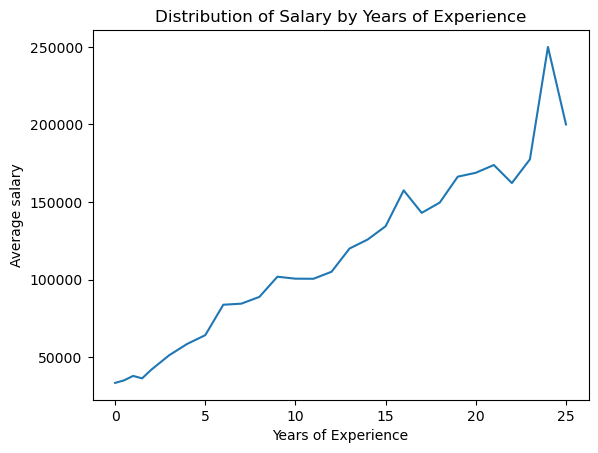

In [17]:
salary_by_experience.plot(kind='line');
plt.title('Distribution of Salary by Years of Experience');
plt.xlabel('Years of Experience');
plt.ylabel('Average salary');
plt.show();

`d)`  To make use of Job Title column lets create bool flag based on word existiance


List of words:

* Director
* Junior
* Senior
* Manager
* Analyst
* Engineer

**This question is completed for you**

In [18]:
flag_words = ['director', 'junior', 'senior', 'manager', 'analyst', 'engineer']
df['Job Title'] = df['Job Title'].str.lower()

for word in flag_words:
    df['is_' + word] = df['Job Title'].str.contains(word)
    
df = df.drop('Job Title', axis=1)

`e)` Create a flag for gender where 1 is if a person is male and 0 if the person is not.

In [19]:
df['is_male'] = (df['Gender'] == 'Male').astype(int)

In [20]:
# Viewing a few rows to verify that the flags were applied as expected
df.head(3)

,Age,Gender,Education Level,Years of Experience,Salary,is_director,is_junior,is_senior,is_manager,is_analyst,is_engineer,is_male
0,32.0,Male,Bachelor's,5.0,90000.0,False,False,False,False,False,True,1
1,28.0,Female,Master's,3.0,65000.0,False,False,False,False,True,False,0
2,45.0,Male,PhD,15.0,150000.0,False,False,True,True,False,False,1


`f)` Use statsmodels to fit a linear model to predict salary using each of the features from `a-e`.  These include:
* Gender
* Job TItle
* Years of Experience
* Education

In [21]:
import statsmodels.api as sms

# Since 'Education Level' is categorical, we need to convert it to dummy variables (and drop the first one)to work with the model.
education_dummies = pd.get_dummies(df['Education Level'], drop_first=True, prefix="education").astype(int)

# Using concat to add the dummies to the original df
df = pd.concat([df, education_dummies], axis=1)

df.head(3)

,Age,Gender,Education Level,Years of Experience,Salary,is_director,is_junior,is_senior,is_manager,is_analyst,is_engineer,is_male,education_Master's,education_PhD
0,32.0,Male,Bachelor's,5.0,90000.0,False,False,False,False,False,True,1,0,0
1,28.0,Female,Master's,3.0,65000.0,False,False,False,False,True,False,0,1,0
2,45.0,Male,PhD,15.0,150000.0,False,False,True,True,False,False,1,0,1


In [34]:
# Specifying the columns (variables) to use for the regression model
features = ['is_male', 'is_junior', 'is_senior', 'is_analyst', 'is_manager', 'is_engineer', 'is_director', 'Years of Experience', "education_Master's", 'education_PhD']

In [35]:
# Specifying the features and target variable
X = df[features].astype(float)
y = df['Salary'].astype(float)

In [36]:
# Fitting the model with required constant and reviewing results
reg_model = sms.OLS(y, sms.add_constant(X)).fit()
reg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.915
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     391.7
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          2.41e-187
Time:                        18:57:02   Log-Likelihood:                -4090.6
No. Observations:                 373   AIC:                             8203.
Df Residuals:                     362   BIC:                             8246.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                3.212e+04   2485.604     12.921      0.000    2.72e+04     3.7e+04
is_male              7484.7304   1509.904      4.957      0.000    4515.446    1.05e+04
is_junior           -4492.5634   2458.516     -1.827      0.068   -9327.330     342.203
is_senior            1.307e+04   1976.833      6.610      0.000    9178.417     1.7e+04
is_analyst           -176.3409   2103.878     -0.084      0.933   -4313.698    3961.016
is_manager           4434.5081   1960.352      2.262      0.024     579.400    8289.617
is_engineer          2362.9515   3561.972      0.663      0.508   -4641.805    9367.708
is_director          2.539e+04   3535.194      7.181      0.000    1.84e+04    3.23e+04
Years of Experience  4937.4278    197.548     24.994      0.000    4548.941    5325.914
education_Master's   1.345e+04   2053.896      6.547      0.000    9408.638    1.75e+04
education_PhD        2.327e+04   2801.927      8.304      0.000    1.78e+04    2.88e+04
==============================================================================
Omnibus:                      130.784   Durbin-Watson:                   1.815
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1091.992
Skew:                           1.230   Prob(JB):                    7.53e-238
Kurtosis:                      11.013   Cond. No.                         63.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

<a id='interpretation'></a>
### Part III - Interpret Results

`1.` Consider you are tasked with finding which features in your linear model are significantly related to salary.  Were there any features that were not significantly related to salary in your first model?  If not, remove those features and fit a new model.  Only keep the features that were significant from the original model.

In [37]:
# After reviewing the p values, is_junior (0.068), is_analyst(0.933), and is_engineer (0.508) aren't statistically significant based on a cutoff of 0.05. Therefore, I'll drop them and fit a new model.
features = ['is_male','is_senior', 'is_manager', 'is_director', 'Years of Experience', "education_Master's", 'education_PhD']
X = df[features].astype(float)
y = df['Salary'].astype(float)
reg_model = sms.OLS(y, sms.add_constant(X)).fit()
reg_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                 Salary   R-squared:                       0.914
Model:                            OLS   Adj. R-squared:                  0.913
Method:                 Least Squares   F-statistic:                     557.4
Date:                Thu, 18 Jun 2026   Prob (F-statistic):          1.46e-190
Time:                        19:01:43   Log-Likelihood:                -4092.6
No. Observations:                 373   AIC:                             8201.
Df Residuals:                     365   BIC:                             8233.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                2.876e+04   1677.411     17.146      0.000    2.55e+04    3.21e+04
is_male              7629.6521   1481.834      5.149      0.000    4715.649    1.05e+04
is_senior            1.445e+04   1820.427      7.936      0.000    1.09e+04     1.8e+04
is_manager           4284.6595   1822.582      2.351      0.019     700.579    7868.740
is_director          2.498e+04   3503.028      7.131      0.000    1.81e+04    3.19e+04
Years of Experience  5104.4388    177.226     28.802      0.000    4755.927    5452.950
education_Master's   1.404e+04   2032.078      6.908      0.000       1e+04     1.8e+04
education_PhD        2.308e+04   2760.740      8.360      0.000    1.77e+04    2.85e+04
==============================================================================
Omnibus:                      126.635   Durbin-Watson:                   1.790
Prob(Omnibus):                  0.000   Jarque-Bera (JB):             1010.895
Skew:                           1.196   Prob(JB):                    3.07e-220
Kurtosis:                      10.702   Cond. No.                         60.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

`a)` With each additional year of experience, what is the expected change in salary?  What is the 95% confidence interval of the change?

**Your Answer Here**

`b)` What is the expected difference in salary between someone with a senior title and someone with none of the other title indications?

**Your Answer Here**

`c)` What is the expected difference in salary between someone with a PhD and an individual with no PhD nor master's degree?  What is the 95% confidence interval of the change?

**Your Answer Here**

`d)` If a male employee has 5 years of experience as a senior engineer with a bachelor's degree, what is the expected salary of the employee?

**Your Answer Here**

`e)` Imagine that the employee in question `d)` actually has a salary of $110,000, what would the residual be for this employee?

**Your Answer Here**

`f)` How well do you think your model fits?  What metrics or plots would you consider to understand if this model does a good job of predicting salary?

In [26]:
### Your work here

**Your Answer Here**